In [1]:
import os

# Your exact username from the screenshot (two a's)
os.environ['KAGGLE_USERNAME'] = "abdulwasaytabbaa"
os.environ['KAGGLE_KEY'] = "KGAT_a046bbe7ba6f041c6103aeb45eed1b28"

# We are using a different, more stable version of the dataset
!kaggle datasets download -d chetankv/dogs-cats-images

# Unzip it
# The -q means 'quiet' and the -o means 'overwrite' (no more prompts!)
!unzip -qo dogs-cats-images.zip -d train_data

print("If there is no 403 error above, your data is ready in the 'train_data' folder!")

Dataset URL: https://www.kaggle.com/datasets/chetankv/dogs-cats-images
License(s): CC0-1.0
100% 435M/435M [00:28<00:00, 16.3MB/s]

If there is no 403 error above, your data is ready in the 'train_data' folder!


In [2]:
import os

# Look inside the folder we created
path = 'train_data/dataset'
if os.path.exists(path):
    print("Folders found:", os.listdir(path))

    # Check training images
    train_path = os.path.join(path, 'training_set')
    if os.path.exists(train_path):
        print("Training categories:", os.listdir(train_path))

Folders found: ['test_set', 'training_set']
Training categories: ['cats', 'dogs']


In [3]:
import os

# This will list every folder inside 'train_data'
for root, dirs, files in os.walk('train_data'):
    level = root.replace('train_data', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")

train_data/
    dataset/
        test_set/
            cats/
            dogs/
        training_set/
            cats/
            dogs/
    dog vs cat/
        dataset/
            test_set/
                cats/
                dogs/
            training_set/
                cats/
                dogs/


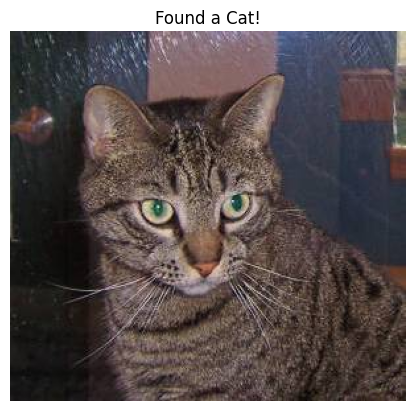

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Updated path: Note the folder structure from your screenshot
# I will use a path that definitely exists based on your tree
sample_cat = 'train_data/dataset/training_set/cats/cat.1.jpg'

# Let's check if the file exists before reading it to avoid the red error
if os.path.exists(sample_cat):
    img = mpimg.imread(sample_cat)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Found a Cat!")
    plt.show()
else:
    # If cat.1.jpg doesn't work, this will list the first 5 images in that folder
    # so you can see the correct filenames
    actual_files = os.listdir('train_data/dataset/training_set/cats/')
    print("File not found. The first 5 files in that folder are:")
    print(actual_files[:5])

In [23]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D,Flatten,MaxPooling2D,Dense,BatchNormalization,Dropout

In [6]:
# generators is like batches
# you divide all the data so the ram
# dosent get overloaded
# so it is useful to process large amount of data

In [7]:
train_dataset = keras.utils.image_dataset_from_directory(
    directory = '/content/train_data/dataset/training_set',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

Found 8000 files belonging to 2 classes.


In [8]:
test_dataset = keras.utils.image_dataset_from_directory(
    directory = '/content/train_data/dataset/test_set',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

Found 2000 files belonging to 2 classes.


In [9]:
# currently the images are stored in a numpy array

In [10]:
# the problem is that the values are from 0 till 255
# we need to make it between 0 to 1
# so we need to normalize it

In [11]:
def process(image,label):
  image = tf.cast(image/255,tf.float32)
  return image,label
train_dataset = train_dataset.map(process)
test_dataset = test_dataset.map(process)

In [12]:
# create cnn model

In [65]:
model = Sequential()

# Layer 1
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Layer 2
model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Layer 3 - Increased filters to 128
model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2))

model.add(Conv2D(254, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2))

model.add(Flatten())

# DENSE SECTION - This is where the overfitting usually happens
# Increased Dropout to 0.4 to force the model to find multiple patterns
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(1, activation='sigmoid'))

In [66]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 254)    │       292,862 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 28, 28, 254)    │         1,016 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 14, 14, 254)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 49784)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │     6,372,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,770,871 (25.83 MB)

 Trainable params: 6,769,915 (25.83 MB)

 Non-trainable params: 956 (3.73 KB)

In [69]:

model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [70]:
history = model.fit(train_dataset,epochs=10,validation_data=test_dataset)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 109ms/step - accuracy: 0.5629 - loss: 0.8614 - val_accuracy: 0.5810 - val_loss: 0.6699
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step - accuracy: 0.6187 - loss: 0.6493 - val_accuracy: 0.6520 - val_loss: 0.6258
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.6724 - loss: 0.6119 - val_accuracy: 0.6345 - val_loss: 0.6608
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 101ms/step - accuracy: 0.7084 - loss: 0.5595 - val_accuracy: 0.7080 - val_loss: 0.5522
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - accuracy: 0.7460 - loss: 0.5109 - val_accuracy: 0.7585 - val_loss: 0.4990
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 101ms/step - accuracy: 0.7915 - loss: 0.4586 - val_accuracy: 0.7675 - val_loss: 0.4991
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step - accuracy: 0.8196 - loss: 0.3930 - val_accuracy: 0.7660 - val_loss: 0.5056
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - accuracy: 0.8589 - loss: 0

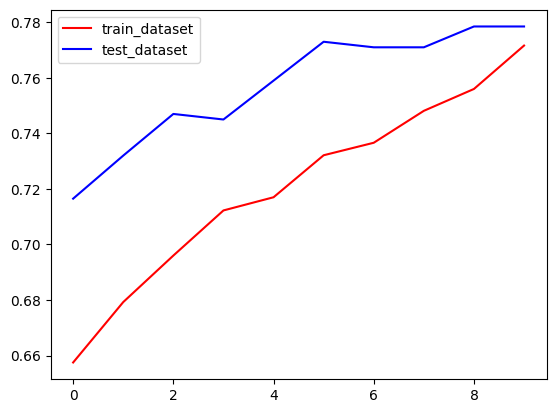

In [59]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color ='red',label = 'train_dataset')
plt.plot(history.history['val_accuracy'],color ='blue',label = 'test_dataset')
plt.legend()
plt.show()

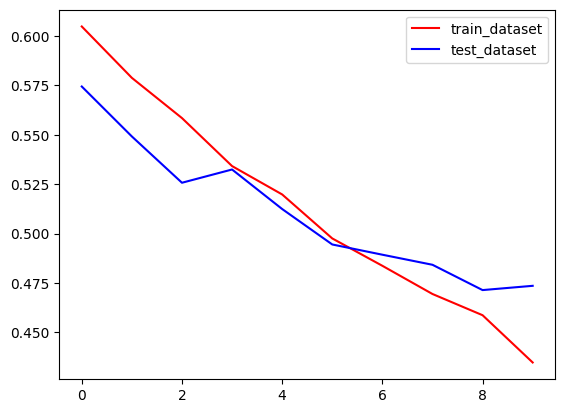

In [60]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],color ='red',label = 'train_dataset')
plt.plot(history.history['val_loss'],color ='blue',label = 'test_dataset')
plt.legend()
plt.show()

In [ ]:
# ways to reduce overfitting
# add more data
# data augumentation
# l1/l2 regularization
# dropout layer
# batch norm
# reduce complexity